In [1]:
#### ------------------------------------------------------------------------------------------
#### author: Ranjan Barman, date: Jul 24, 2025 (modified for POST_NAT_BRCA)
#### Compute 12 NPIFs from immune-only nuclei based on HoverNet prediction, using MPP = 0.248
#### Removes outliers for Major Axis and Minor Axis using IQR
#### Filters top 25% tiles based on number of immune nuclei
#### ------------------------------------------------------------------------------------------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set working directory
_wpath_ = "/data/Lab_ruppin/Ranjan/HnE/"
os.makedirs(_wpath_, exist_ok=True)
os.chdir(_wpath_)
print("Working directory:", _wpath_)

# Dataset and output
dataset_name = "POST_NAT_BRCA"
input_folder = f"{dataset_name}/HoverNet/outputs/"
output_file_path = f"{dataset_name}/HoverNet/outputs/POST_NAT_BRCA_HoverNet_ImmuneOnly_NPIFs_Filtered_Tiles_Top25Q.csv"

columns_to_compute = ["Area", "Major Axis", "Minor Axis", "Perimeter", "Eccentricity", "Circularity"]
MPP = 0.248  # microns per pixel for 40X

# Function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Store results
results = []

# Slide folders: exclude jobs, models folders
slide_dirs = [f for f in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, f)) and not f.startswith(("jobs", "models"))]

for slide_name in slide_dirs:
    file_path = os.path.join(input_folder, slide_name, "features3", f"{slide_name}.csv")
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}, skipping...")
        continue

    df = pd.read_csv(file_path)

    # Convert units
    df["Area"] = df["Area"] * (MPP ** 2)
    df["Major Axis"] = df["Major Axis"] * MPP
    df["Minor Axis"] = df["Minor Axis"] * MPP
    df["Perimeter"] = df["Perimeter"] * MPP

    # Remove outliers
    df = remove_outliers(df, "Major Axis")
    df = remove_outliers(df, "Minor Axis")

    # Count immune nuclei per tile
    tile_nucleus_counts = df.groupby("Tile")["Nucleus ID"].count().reset_index()
    tile_nucleus_counts.rename(columns={"Nucleus ID": "Immune_Nucleus_Count"}, inplace=True)

    total_tiles = tile_nucleus_counts.shape[0]
    percentile_75 = tile_nucleus_counts["Immune_Nucleus_Count"].quantile(0.75)
    top_tiles = tile_nucleus_counts[tile_nucleus_counts["Immune_Nucleus_Count"] >= percentile_75]

    num_filtered_tiles = top_tiles.shape[0]

    print(f"Slide: {slide_name}")
    print(f"  - Total tiles with immune nuclei: {total_tiles}")
    print(f"  - 75th percentile threshold: {percentile_75}")
    print(f"  - Top 25% tiles: {num_filtered_tiles}")

    # Filter DF for selected tiles
    df_filtered = df[df["Tile"].isin(top_tiles["Tile"])]
    
    if df_filtered.empty:
        print(f"  - No valid tiles in top 25% for slide {slide_name}, skipping...\n")
        continue

    # Compute mean and std of features
    mean_values = df_filtered[columns_to_compute].mean()
    std_values = df_filtered[columns_to_compute].std()

    # Append result
    results.append([slide_name, total_tiles, num_filtered_tiles] + mean_values.tolist() + std_values.tolist())

# Format results
result_df = pd.DataFrame(
    results,
    columns=["Slide_Name", "Total_Tiles", "Filtered_Tiles"] + 
            [f"Mean {col}" for col in columns_to_compute] + 
            [f"Std {col}" for col in columns_to_compute]
)

# Clean up values
result_df.replace([np.inf, -np.inf], np.nan, inplace=True)
result_df.fillna(result_df.mean(numeric_only=True), inplace=True)
result_df.fillna(0, inplace=True)



Working directory: /data/Lab_ruppin/Ranjan/HnE/
Slide: 99798_2068_tiles
  - Total tiles with immune nuclei: 1925
  - 75th percentile threshold: 17.0
  - Top 25% tiles: 501
Slide: 102194_3173_tiles
  - Total tiles with immune nuclei: 2963
  - 75th percentile threshold: 15.0
  - Top 25% tiles: 776
Slide: 102195_2284_tiles
  - Total tiles with immune nuclei: 2267
  - 75th percentile threshold: 28.0
  - Top 25% tiles: 586
Slide: 99795_3386_tiles
  - Total tiles with immune nuclei: 3209
  - 75th percentile threshold: 9.0
  - Top 25% tiles: 888
Slide: 99810_2730_tiles
  - Total tiles with immune nuclei: 2597
  - 75th percentile threshold: 11.0
  - Top 25% tiles: 660
Slide: 102184_1621_tiles
  - Total tiles with immune nuclei: 1539
  - 75th percentile threshold: 15.0
  - Top 25% tiles: 388
Slide: 99836_877_tiles
  - Total tiles with immune nuclei: 717
  - 75th percentile threshold: 7.0
  - Top 25% tiles: 215
Slide: 99848_1029_tiles
  - Total tiles with immune nuclei: 989
  - 75th percentile t

In [2]:
result_df

,Slide_Name,Total_Tiles,Filtered_Tiles,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,99798_2068_tiles,1925,501,6.111903,3.358655,2.492488,9.691686,0.625723,0.806776,1.986552,0.649179,0.397345,1.709958,0.149402,0.068684
1,102194_3173_tiles,2963,776,5.791998,3.284621,2.401913,9.406157,0.635216,0.806811,2.167951,0.720187,0.424303,1.879512,0.149062,0.069186
2,102195_2284_tiles,2267,586,6.238862,3.399858,2.480719,9.741178,0.637054,0.806645,2.463193,0.756185,0.471428,2.008097,0.151395,0.069492
3,99795_3386_tiles,3209,888,5.581172,3.246108,2.350282,9.281217,0.646567,0.797749,2.132577,0.689162,0.437326,1.862464,0.147779,0.072396
4,99810_2730_tiles,2597,660,5.243828,3.145310,2.291032,8.978143,0.636361,0.805022,1.840061,0.666072,0.375975,1.689702,0.152857,0.068447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,102197_1224_tiles,1180,304,6.513147,3.453137,2.552246,9.922336,0.625654,0.809144,2.728182,0.821714,0.492946,2.161202,0.149247,0.069187
92,102198_885_tiles,855,218,5.889033,3.365713,2.390343,9.553674,0.658143,0.796670,2.175430,0.739371,0.423787,1.930445,0.148181,0.072816
93,99861_4107_tiles,3958,1058,5.729026,3.302988,2.362266,9.393716,0.654503,0.794820,2.474008,0.760538,0.476801,2.049561,0.147764,0.072743
94,99809_4161_tiles,3952,1061,5.544455,3.224116,2.350642,9.236070,0.633856,0.804040,2.051087,0.719722,0.398521,1.865666,0.153828,0.072871


In [3]:
# Extract Slide_ID from Slide_Name (prefix before first underscore)
result_df['Slide_ID'] = result_df['Slide_Name'].str.split('_').str[0]

# Group by Slide_ID and average numeric columns
patient_avg_df = result_df.groupby('Slide_ID').mean(numeric_only=True)

# Save patient-level results
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
patient_avg_df.to_csv(output_file_path)
print(f"Converted results saved to: {output_file_path}")

patient_avg_df


Converted results saved to: POST_NAT_BRCA/HoverNet/outputs/POST_NAT_BRCA_HoverNet_ImmuneOnly_NPIFs_Filtered_Tiles_Top25Q.csv


,Total_Tiles,Filtered_Tiles,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
Slide_ID,,,,,,,,,,,,,,
102174,3010,754,6.324498,3.444595,2.507662,9.868560,0.639522,0.804120,2.191528,0.718363,0.418309,1.870138,0.149379,0.072247
102175,1352,357,6.968359,3.630750,2.586662,10.338270,0.660456,0.793758,3.033119,0.861657,0.567950,2.372700,0.144893,0.074991
102176,1442,386,7.149163,3.696185,2.607033,10.501393,0.664448,0.790910,3.097806,0.893065,0.554460,2.398472,0.148089,0.076237
102177,1362,366,6.830735,3.513571,2.607851,10.142307,0.626800,0.807798,3.081417,0.836355,0.549991,2.286572,0.146359,0.065193
102178,1237,315,6.011641,3.378721,2.423322,9.621849,0.650832,0.801057,2.253680,0.748349,0.427522,1.950581,0.147026,0.072984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99861,3958,1058,5.729026,3.302988,2.362266,9.393716,0.654503,0.794820,2.474008,0.760538,0.476801,2.049561,0.147764,0.072743
99862,2729,689,5.577820,3.287050,2.325585,9.310929,0.660259,0.796841,2.071152,0.736734,0.404588,1.916604,0.147412,0.076249
99866,1070,289,5.245552,3.161266,2.305480,9.088667,0.637423,0.792248,1.635059,0.627292,0.356424,1.659127,0.150495,0.080791


In [4]:
patient_avg_df.describe()

,Total_Tiles,Filtered_Tiles,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,2427.979167,648.895833,6.077611,3.358465,2.449932,9.634007,0.637591,0.801555,2.371875,0.745117,0.455817,1.981963,0.149804,0.070645
std,1023.388510,274.279630,0.791710,0.178790,0.155726,0.560820,0.018592,0.006789,0.486606,0.078626,0.073877,0.245940,0.003089,0.004625
min,717.000000,214.000000,5.073304,3.057767,2.266653,8.828008,0.537222,0.786499,1.635059,0.582095,0.354964,1.537928,0.143894,0.054570
25%,1584.750000,414.750000,5.580334,3.244827,2.350552,9.270314,0.627239,0.796844,2.066136,0.688848,0.405203,1.811466,0.147603,0.068018
50%,2272.500000,607.000000,5.903151,3.341990,2.416061,9.546583,0.637338,0.801647,2.306888,0.743196,0.443561,1.946445,0.149391,0.070806
75%,3067.250000,848.750000,6.321734,3.428800,2.496281,9.841475,0.650068,0.806049,2.551743,0.790700,0.481904,2.094880,0.151928,0.073043
max,5159.000000,1338.000000,9.700173,4.052762,3.192290,12.052685,0.670879,0.824785,4.456841,1.009659,0.758868,2.914714,0.160220,0.081263


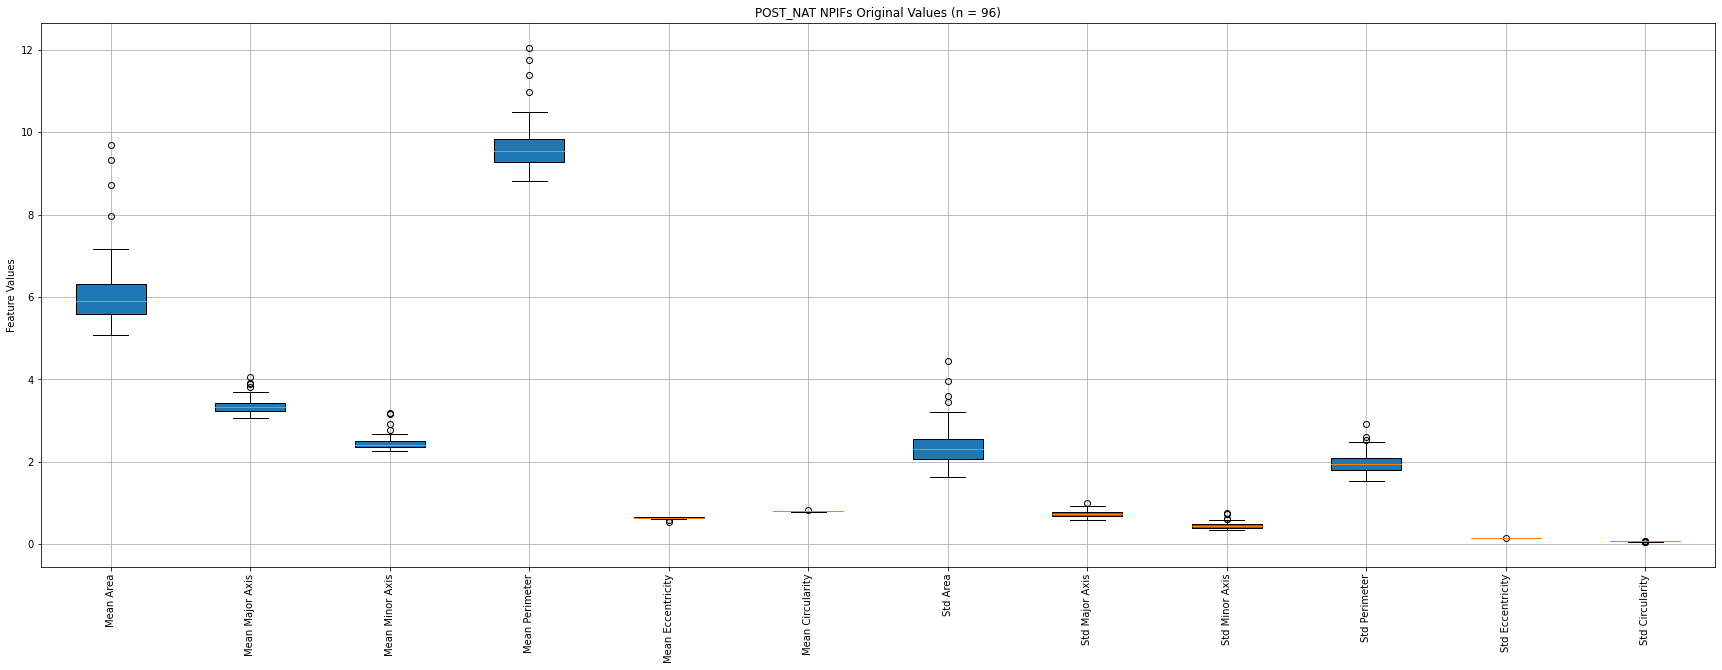

In [6]:
# Import required library
import matplotlib.pyplot as plt

# Select only NPIF features
post_nat_features = patient_avg_df.iloc[:, 2:]
n_post_nat = post_nat_features.shape[0]

# Boxplot
plt.figure(figsize=(30, 10))
plt.boxplot(post_nat_features.values, labels=post_nat_features.columns, vert=True, patch_artist=True)
plt.xticks(rotation=90)
plt.title(f"POST_NAT NPIFs Original Values (n = {n_post_nat})")
plt.ylabel("Feature Values")
plt.grid(True)
plt.show()